# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ Majorana - MPS optimization

Created: 15-07-2026

Objectives:
* Like [previous notebook](z2_f_x_z2_t_mps_optimization.ipynb) but for Majorana Hamiltonians. Also extract $\rho$ as in [this notebook](z2_f_x_z2_t_majorana_obc_tripartite_schmidt_decomposition.ipynb).

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from itertools import product
from functools import reduce
from operator import mul

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Import states

In [13]:
triv_groundstates = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [14]:
nontriv_groundstates = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')['psi']
    for i in range(0, 101, 5)
]

In [15]:
len(triv_groundstates), len(nontriv_groundstates),

(21, 21)

# Definitions

In [16]:
L = 10

In [17]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [18]:
parameters = np.linspace(0, 1, 201)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [19]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [20]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [21]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [22]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [23]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [24]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [25]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [26]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [27]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [28]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [29]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [30]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [31]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    return A_opt, tnopt.losses, tnopt.loss_best

In [32]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [33]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [34]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [35]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [36]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [37]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [38]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

## Calculate $\rho$

In [39]:
spin_change_of_basis_matrix = 0.5*np.array([
    [1, 1, 0, 0],
    [0, 0, 1, 1j],
    [0, 0, 1, -1j],
    [1, -1, 0, 0]
])

ferm_change_of_basis_matrix = np.array([
    [1, -1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
])

In [40]:
spin_change_of_basis_matrix @ np.array([1,0,0,0])

array([0.5+0.j, 0. +0.j, 0. +0.j, 0.5+0.j])

In [41]:
simple_spin_ops = 'Izxy'
simple_ferm_ops = 'In+-'

In [42]:
spin_inds = [
    f'{s}{i}'
    for i in range(5)
    for s in 'ab'
]

In [43]:
spin_inds

['a0', 'b0', 'a1', 'b1', 'a2', 'b2', 'a3', 'b3', 'a4', 'b4']

In [44]:
def get_fermionic_rho(quspin_psi, domains_dict, verbose=False):
    # Output rho has indices k0, b0, k1, b1, etc...
    L = domains_dict['num_system_sites']//2

    spin_basis = spin_basis_1d(L, pauli=-1)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    sym_sites = domains_dict['symmetry_sites']
    num_symmetry_sites = len(sym_sites)

    spin_symmetry_sites = [
        i//2 for i in domains_dict['symmetry_sites']
        if (i%2 == 0)
    ]
    
    ferm_symmetry_sites = [
        (i-1)//2 for i in domains_dict['symmetry_sites']
        if (i%2 == 1)
    ]

    num_spin_sym_sites = len(spin_symmetry_sites)
    num_ferm_sym_sites = len(ferm_symmetry_sites)
    num_symmetry_sites = len(sym_sites)

    spin_ops_iter = product(simple_spin_ops, repeat=num_spin_sym_sites)
    spin_indices_iter = product(
        range(len(simple_spin_ops)),
        repeat=num_spin_sym_sites
    )
    spin_iter = zip(spin_indices_iter, spin_ops_iter)

    ferm_ops_iter = product(simple_ferm_ops, repeat=num_ferm_sym_sites)
    ferm_indices_iter = product(
        range(len(simple_ferm_ops)),
        repeat=num_ferm_sym_sites
    )
    ferm_iter = zip(ferm_indices_iter, ferm_ops_iter)

    index = spin_symmetry_sites + ferm_symmetry_sites

    data = np.zeros((4,)*(num_symmetry_sites), dtype=complex)

    if verbose:
        spin_ferm_iter = tqdm(list(product(spin_iter, ferm_iter)))
    else:
        spin_ferm_iter = list(product(spin_iter, ferm_iter))

    for spin_pair, ferm_pair in spin_ferm_iter:
        spin_index, spin_op = spin_pair
        ferm_index, ferm_op = ferm_pair

        spin_op_string = ''.join(spin_op)
        ferm_op_string = ''.join(ferm_op)

        terms = [[f'{spin_op_string}|{ferm_op_string}', [[1, *index]]]]

        op = hamiltonian(
            terms,
            [],
            basis=basis,
            check_herm=False,
            check_symm=False,
        )

        exp = op.expt_value(quspin_psi)

        #print(exp)
        #print(exp.shape)
        #print(data[*spin_index, *ferm_index])
        data[*spin_index, *ferm_index] = exp.item()

    for i in range(num_spin_sym_sites):
        data = np.tensordot(
            spin_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    for i in range(num_spin_sym_sites, num_symmetry_sites):
        data = np.tensordot(
            ferm_change_of_basis_matrix,
            data,
            axes=[[1,], [i,]]
        )

    data = data.reshape((2,)*(2*num_symmetry_sites))

    even_inds = [
        f'{s}{i}'
        for i in domains_dict['symmetry_sites']
        if (i%2 == 0)
        for s in 'kb'
    ]

    odd_inds = [
        f'{s}{i}'
        for i in domains_dict['symmetry_sites']
        if (i%2 == 1)
        for s in 'kb'
    ]

    inds = even_inds + odd_inds

    out = qtn.Tensor(data, inds=inds)
    out = qtn.TensorNetwork([out,])

    return out

# Test

In [86]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(9, 12)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [87]:
psi = triv_groundstates[-1]

In [88]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [89]:
inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

In [90]:
rho = get_fermionic_rho(psi, domains_dict, verbose=True)

  0%|                                                                                                    | 0/64 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_71981/2503371872.py:58: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
100%|██████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 103.43it/s]


In [91]:
rho

TensorNetwork(tensors=1, indices=6)

In [104]:
np.linalg.norm(rho.tensors[0].data)

np.float64(0.5000000000000001)

In [ ]:
rho.tensors[0].data

In [109]:
np.round(rho.tensors[0].data.flatten(), 3)

array([ 0.125-0.j, -0.   -0.j, -0.   +0.j,  0.125-0.j, -0.   -0.j,
       -0.   -0.j,  0.   -0.j,  0.   -0.j, -0.   +0.j,  0.   +0.j,
       -0.   +0.j,  0.   +0.j,  0.125-0.j,  0.   -0.j,  0.   +0.j,
        0.125-0.j,  0.   +0.j, -0.   -0.j, -0.   +0.j, -0.   -0.j,
        0.125-0.j,  0.   +0.j,  0.   +0.j, -0.125+0.j, -0.125-0.j,
       -0.   -0.j, -0.   -0.j,  0.125+0.j, -0.   +0.j, -0.   -0.j,
       -0.   +0.j, -0.   -0.j,  0.   -0.j, -0.   -0.j, -0.   +0.j,
       -0.   +0.j,  0.125-0.j,  0.   -0.j,  0.   -0.j, -0.125+0.j,
       -0.125-0.j, -0.   +0.j, -0.   +0.j,  0.125+0.j, -0.   -0.j,
       -0.   -0.j, -0.   +0.j, -0.   +0.j,  0.125-0.j, -0.   +0.j,
       -0.   -0.j,  0.125-0.j, -0.   +0.j, -0.   -0.j,  0.   -0.j,
        0.   +0.j, -0.   -0.j,  0.   +0.j, -0.   +0.j,  0.   -0.j,
        0.125-0.j, -0.   +0.j, -0.   -0.j,  0.125-0.j])

In [111]:
rdm = rho

In [112]:
rdm_indices = rdm.outer_inds()

k_indices = [s for s in rdm_indices if s.startswith('k')]
b_indices = [s for s in rdm_indices if s.startswith('b')]

rdm_transpose_map = {
    **{s: f'b{s[1:]}' for s in k_indices},
    **{s: f'k{s[1:]}' for s in b_indices}
}

In [114]:
b_indices

['b10', 'b9', 'b11']

In [115]:
out = (
    rdm
    & rdm.reindex(rdm_transpose_map)
)

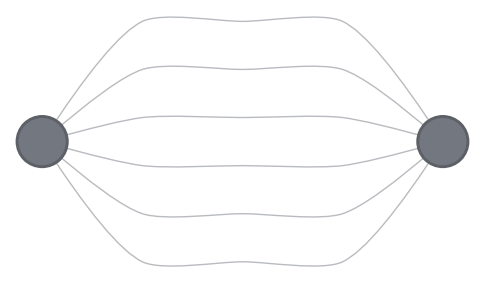

In [116]:
out.draw()

In [117]:
out.contract(inplace=True)

TensorNetwork(tensors=1, indices=0)

In [118]:
out.item()

(-5.5511151231257624e-17+2.0593488530155734e-20j)

In [119]:
out = np.real(out.item())

In [120]:
out

-5.5511151231257624e-17

In [122]:
help(rho.tensors[0].fuse)

Help on method fuse in module quimb.tensor.tensor_core:

fuse(fuse_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Combine groups of indices into single indices.

    Parameters
    ----------
    fuse_map : dict_like or sequence of tuples.
        Mapping like: ``{new_ind: sequence of existing inds, ...}`` or an
        ordered mapping like ``[(new_ind_1, old_inds_1), ...]`` in which
        case the output tensor's fused inds will be ordered. In both cases
        the new indices are created at the minimum axis of any of the
        indices that will be fused.

    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor.



In [123]:
rho

TensorNetwork(tensors=1, indices=6)

In [124]:
M = rho.tensors[0].fuse({
    'k': ['k9', 'k10', 'k11'],
    'b': ['b9', 'b10', 'b11']
}).data

In [126]:
np.trace(M @ M)

np.complex128(-5.551115123125771e-17+2.0593488530156384e-20j)

In [127]:
np.trace(M)

np.complex128(1-2.4875914491681154e-19j)

In [125]:
M

array([[ 1.25000000e-01-3.57323885e-20j, -1.28329405e-18-1.85708413e-16j,
         3.77001547e-17+1.42351224e-17j, -1.07821621e-16-6.13392728e-17j,
        -2.21731362e-17-1.35738415e-17j, -1.13952242e-16-5.73334570e-17j,
         1.25000000e-01-2.12843228e-17j,  9.32578609e-17+1.22545461e-16j],
       [-1.28329405e-18+1.85708413e-16j,  1.25000000e-01-1.84594332e-20j,
        -1.07811775e-16+5.59039095e-17j, -1.39832934e-17-1.83205061e-17j,
         1.04254623e-16-5.62201432e-17j,  1.11118671e-17-1.62782548e-17j,
         9.60913089e-17+1.29455468e-16j, -1.25000000e-01+2.46335899e-17j],
       [ 3.77001547e-17-1.42351224e-17j, -1.07811775e-16-5.59039095e-17j,
         1.25000000e-01-3.36136804e-20j, -5.53347139e-18+4.65855969e-17j,
         1.25000000e-01-3.06116130e-17j,  1.02373810e-16-1.11128868e-16j,
        -2.06995013e-17+1.61968783e-17j, -1.08587180e-16-6.14080507e-17j],
       [-1.07821621e-16+6.13392728e-17j, -1.39832934e-17+1.83205061e-17j,
        -5.53347139e-18-4.65855969e

In [106]:
np.linalg.norm(rho.tensors[0].data.flatten())

np.float64(0.5000000000000001)

In [107]:
rho.tensors[0].data.flatten()

array([ 1.25000000e-01-3.57323885e-20j, -1.28329405e-18-1.85708413e-16j,
       -1.28329405e-18+1.85708413e-16j,  1.25000000e-01-1.84594332e-20j,
       -2.21731362e-17-1.35738415e-17j, -1.13952242e-16-5.73334570e-17j,
        1.04254623e-16-5.62201432e-17j,  1.11118671e-17-1.62782548e-17j,
       -2.21731362e-17+1.35738415e-17j,  1.04254623e-16+5.62201432e-17j,
       -1.13952242e-16+5.73334570e-17j,  1.11118671e-17+1.62782548e-17j,
        1.25000000e-01-1.88722107e-20j,  1.62651232e-18-1.66661659e-16j,
        1.62651232e-18+1.66661659e-16j,  1.25000000e-01-2.69348531e-20j,
        3.77001547e-17+1.42351224e-17j, -1.07821621e-16-6.13392728e-17j,
       -1.07811775e-16+5.59039095e-17j, -1.39832934e-17-1.83205061e-17j,
        1.25000000e-01-2.12843228e-17j,  9.32578609e-17+1.22545461e-16j,
        9.60913089e-17+1.29455468e-16j, -1.25000000e-01+2.46335899e-17j,
       -1.25000000e-01-3.05083052e-17j, -9.52138261e-17-1.02118387e-16j,
       -1.02373810e-16-1.11128868e-16j,  1.25000000

In [92]:
rho.reindex({f'k{i}': f'b{i}' for i in range(9, 12)}).contract()

np.complex128(1-2.4875914491681154e-19j)

In [93]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [94]:
rho_purity

-5.5511151231257624e-17

In [95]:
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)

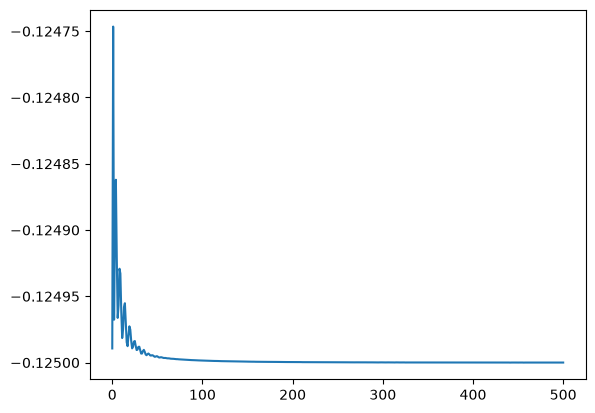

In [96]:
plt.plot(opt_out[1])

In [97]:
opt_out[1][-1]

-0.12499997019767761

In [73]:
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

ValueError: substring not found

In [101]:
defect_opt_out[0]

array([9.9946284e-01, 6.0107854e-05, 6.0091083e-05, 1.0260221e-06,
       1.0183302e-06, 3.0331290e-07, 2.9979378e-07, 1.4094365e-08,
       1.9208556e-10], dtype=float32)

In [102]:
defect_opt_out[3], defect_opt_out[4]

(np.complex128(0.9999997006544401-5.051514762044462e-15j),
 np.complex128(0.9999999619757411-4.912736883966318e-15j))

In [103]:
defect_opt_out[5], defect_opt_out[6]

(np.complex128(0.9999999020371729+1.6148749004685214e-12j),
 np.complex128(0.9999999688761947+1.769279167618265e-13j))

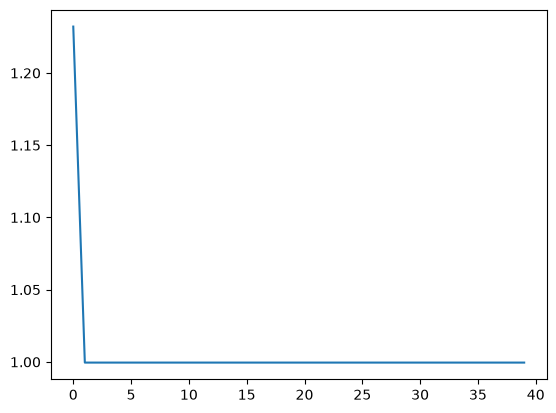

In [104]:
plt.plot(defect_opt_out[-2])

# Sweep

In [128]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(8, 13)),
    'left_defect_sites': [8, 9],
    'right_defect_sites': [11, 12],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [129]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [130]:
inds = (
    [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
    + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
)

In [131]:
rho_traces = list()
triv_defect_results = list()
triv_opt_results = list()

for psi in tqdm(triv_groundstates):
    rho = get_fermionic_rho(psi, domains_dict)
    rho_traces.append(
        rho.reindex({f'k{i}': f'b{i}' for i in range(8, 13)}).contract()
    )
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    triv_opt_results.append(opt_out)
    triv_defect_results.append(defect_opt_out)

  0%|                                                                                                    | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_71981/2503371872.py:58: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  op = hamiltonian(
/Users/kierancooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████| 21/21 [03:22<00:00,  9.65s/it]

In [120]:
nontriv_defect_results = list()
nontriv_opt_results = list()

for psi in tqdm(nontriv_groundstates):
    qt_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
    rho_purity = get_purity_from_quimb_rdm(rho)
    opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
    defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

    nontriv_opt_results.append(opt_out)
    nontriv_defect_results.append(defect_opt_out)

 43%|██████████████████████████████████████████████████████████████████████████▏                                                                                                  | 9/21 [00:37<00:50,  4.23s/it]E0806 14:17:52.585846   26774 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %dot.36 = c64[32,32]{1,0} dot(%constant.1, %constant.3), lhs_contracting_dims={1}, rhs_contracting_dims={0}, metadata={op_name="jit(MakeArrayFn)/jvp()/dot_general" stack_frame_id=161}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0806 14:17:52.629399   26748 slow_operation_alarm.cc:140] The operation took 1.043618775s
Consta

# Debug

In [132]:
psi = triv_groundstates[-1]

In [133]:
rho

TensorNetwork(tensors=1, indices=10)

In [134]:
rho.reindex({f'k{i}': f'b{i}' for i in range(8, 13)}).contract()

np.complex128(1-2.487591449168115e-19j)

In [135]:
rho_purity = get_purity_from_quimb_rdm(rho)

In [136]:
rho_purity

1.3457965860354688e-31

But we are getting negative scores...?

## Analyze results
### Trivial

In [137]:
rho_traces

[np.complex128(1.0000000000000042+1.9455891368015983e-17j),
 np.complex128(0.999999999999995-2.5536428730223193e-17j),
 np.complex128(1.0000000000000058-2.2268368889075632e-17j),
 np.complex128(1.0000000000000002+2.0880557184673092e-18j),
 np.complex128(1.0000000000000233+2.6516699830526476e-17j),
 np.complex128(1.0000000000000078-1.4999331853122043e-17j),
 np.complex128(0.9999999999999989-5.327915605028865e-18j),
 np.complex128(1.000000000000004+1.5243208662235984e-18j),
 np.complex128(1.0000000000000047+1.5306134896369948e-18j),
 np.complex128(0.9999999999999993-4.2465475767829657e-19j),
 np.complex128(1.000000000000004+4.078739717880848e-20j),
 np.complex128(1.000000000000005-7.781391155104562e-20j),
 np.complex128(0.9999999999999889+6.614835432437512e-20j),
 np.complex128(1.000000000000009+3.5509800830408777e-22j),
 np.complex128(0.9999999999999917-3.800908659032019e-20j),
 np.complex128(1.0000000000000164+5.826149784615568e-20j),
 np.complex128(1.0000000000000289+1.598582425501137

In [138]:
mps_scores = [l[1][-1] for l in triv_opt_results]

In [139]:
mps_scores

[-1.1920928955078125e-07,
 -0.0013785362243652344,
 -0.006052374839782715,
 -0.01481926441192627,
 -0.028208613395690918,
 -0.04597294330596924,
 -0.07079899311065674,
 -0.13638490438461304,
 -0.1571221947669983,
 -0.1630498468875885,
 -0.11317002773284912,
 -0.11614030599594116,
 -0.11852367222309113,
 -0.1205543577671051,
 -0.12210783362388611,
 -0.1232413649559021,
 -0.12401722371578217,
 -0.12450943887233734,
 -0.12480548024177551,
 -0.12495449185371399,
 -0.12499889731407166]

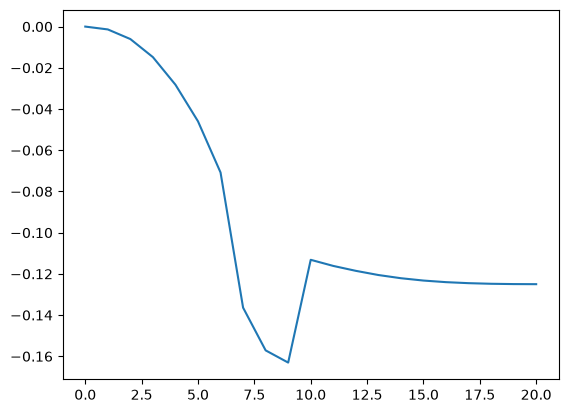

In [140]:
plt.plot(mps_scores)

In [165]:
overlaps = [l[-1] for l in triv_defect_results]

In [166]:
overlaps

[np.float32(0.9998209),
 np.float32(0.99789524),
 np.float32(0.986469),
 np.float32(0.99085534),
 np.float32(0.9638438),
 np.float32(0.9118259),
 np.float32(0.8868308),
 np.float32(0.94247544),
 np.float32(0.6338397),
 np.float32(0.86559784),
 np.float32(0.7423158),
 np.float32(0.34957275),
 np.float32(0.5531568),
 np.float32(0.4963132),
 np.float32(0.5660959),
 np.float32(0.545322),
 np.float32(0.60294074),
 np.float32(0.5142083),
 np.float32(0.74791044),
 np.float32(0.35872185),
 np.float32(0.56697065)]

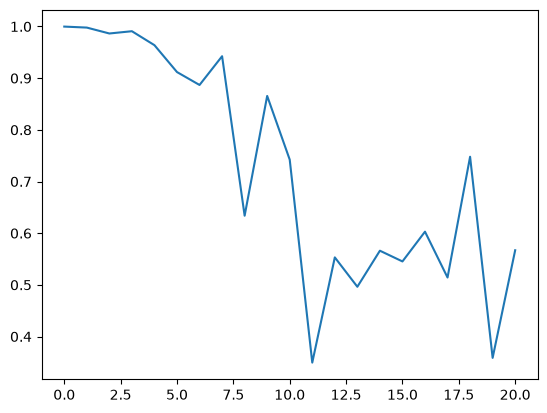

In [167]:
plt.plot(overlaps)

In [168]:
n1_indices = np.array([
    [l[3], l[4]]
    for l in triv_defect_results
])

In [169]:
np.round(n1_indices, 3)

array([[ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.j   ],
       [ 1.   +0.j   ,  1.   +0.001j],
       [ 1.   +0.j   ,  0.998-0.002j],
       [ 0.998+0.j   ,  0.997+0.004j],
       [ 1.   +0.j   ,  0.999+0.001j],
       [ 1.   -0.j   ,  0.985-0.008j],
       [ 1.   +0.j   ,  0.999+0.003j],
       [ 1.   +0.j   ,  0.8  +0.009j],
       [ 1.   +0.j   ,  0.991+0.006j],
       [ 0.92 +0.j   , -0.348+0.014j],
       [ 0.957-0.j   , -0.518-0.021j],
       [ 0.367+0.j   ,  0.422+0.032j],
       [ 0.994+0.j   , -0.466-0.021j],
       [ 0.764-0.j   , -0.107+0.006j],
       [-0.552+0.j   ,  0.922+0.004j],
       [-0.018-0.j   ,  0.704-0.004j],
       [ 0.497-0.j   ,  0.434-0.002j],
       [ 0.311-0.j   ,  0.821+0.001j],
       [ 0.196-0.j   ,  0.068+0.j   ],
       [ 0.013+0.j   , -0.478+0.j   ]])

In [170]:
cocyle_indices = np.array([
    [l[5], l[6]]
    for l in triv_defect_results
])

In [171]:
cocyle_indices

array([[1.        +1.03374254e-12j, 1.00000003+1.14652732e-12j],
       [1.00000004+1.68606906e-10j, 0.9999999 -1.98519035e-10j],
       [1.00000002+6.84326207e-11j, 1.0000002 -8.46456794e-11j],
       [0.99999992-1.83088933e-10j, 1.0000001 -7.12542469e-10j],
       [1.00000005-8.92231289e-11j, 0.99999984-1.19399990e-10j],
       [1.00000004-4.39208045e-12j, 1.0000001 -2.99545257e-10j],
       [0.99999987+1.12555687e-10j, 0.99999992+4.03380712e-09j],
       [0.99999999+1.59189267e-09j, 0.99999996+1.26961003e-09j],
       [0.99999995+2.14614021e-11j, 1.00000002-1.19678102e-08j],
       [0.99999995+1.21169644e-10j, 0.99999999-4.16351065e-10j],
       [0.99999993+5.56787791e-09j, 0.99999998-3.21286884e-08j],
       [0.99952172-1.94041657e-03j, 0.99944632+1.64909287e-03j],
       [0.99999994-8.58030622e-09j, 0.99999999-2.32196482e-08j],
       [1.00000001+4.50065263e-11j, 1.00000002-1.13332383e-08j],
       [1.00000003+9.45234158e-09j, 0.99999995-1.02848460e-08j],
       [0.99999996-2.0457

In [172]:
np.round(cocyle_indices, 3)

array([[1.   +0.j   , 1.   +0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   -0.j   , 1.   -0.j   ],
       [1.   -0.j   , 1.   -0.j   ],
       [1.   -0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   +0.j   ],
       [1.   +0.j   , 1.   +0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   -0.002j, 0.999+0.002j],
       [1.   -0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   -0.j   ],
       [1.   -0.j   , 1.   +0.j   ],
       [1.   -0.j   , 1.   -0.j   ],
       [1.   -0.j   , 1.   +0.j   ],
       [1.   -0.j   , 1.   -0.j   ],
       [1.   +0.j   , 1.   +0.j   ],
       [1.   +0.j   , 1.   +0.j   ]])

### Nontrivial

In [98]:
mps_scores = [l[1][-1] for l in nontriv_opt_results]

In [99]:
mps_scores

[2.2530555725097656e-05,
 2.8312206268310547e-06,
 0.0001055598258972168,
 0.00010186433792114258,
 0.0002479851245880127,
 0.0004672706127166748,
 0.0009875595569610596,
 0.0019185245037078857,
 0.0037381350994110107,
 0.0063505470752716064,
 0.013803601264953613,
 0.006532818078994751,
 0.0035300850868225098,
 0.001819312572479248,
 0.0009203255176544189,
 0.00044411420822143555,
 0.0002161860466003418,
 0.00010648369789123535,
 0.0001310408115386963,
 1.2516975402832031e-06,
 2.6524066925048828e-05]

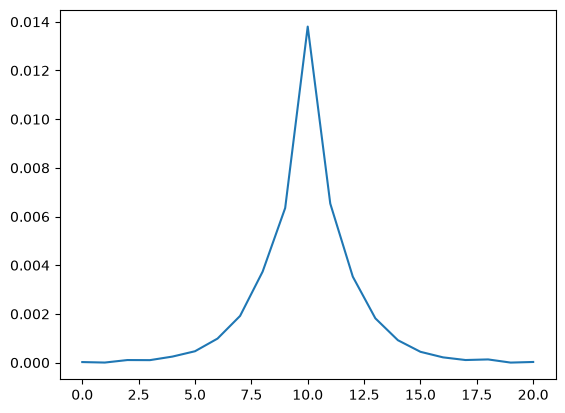

In [100]:
plt.plot(mps_scores)

In [101]:
n1_indices = np.array([
    [l[3], l[4]]
    for l in nontriv_defect_results
])

In [102]:
np.round(n1_indices, 3)

array([[-0.166+0.j,  0.985-0.j],
       [-1.   -0.j,  0.775-0.j],
       [-0.991-0.j, -1.   +0.j],
       [-0.445+0.j, -0.989-0.j],
       [-0.999-0.j,  0.723-0.j],
       [-0.999+0.j,  0.202-0.j],
       [-0.951+0.j, -0.988+0.j],
       [-0.982+0.j, -0.605+0.j],
       [-0.995+0.j, -0.677+0.j],
       [-0.946+0.j, -0.964+0.j],
       [-0.664+0.j,  0.265+0.j],
       [-0.976-0.j, -0.945-0.j],
       [ 0.251+0.j, -0.316-0.j],
       [-0.914-0.j, -0.165-0.j],
       [-0.976+0.j, -0.963+0.j],
       [-0.952-0.j, -0.98 +0.j],
       [-0.997+0.j, -0.277+0.j],
       [-0.823+0.j, -0.124+0.j],
       [-0.441+0.j, -0.77 +0.j],
       [-0.974-0.j, -0.065+0.j],
       [-0.898+0.j, -0.9  -0.j]])

In [103]:
cocyle_indices = np.array([
    [l[5], l[6]]
    for l in nontriv_defect_results
])

In [104]:
cocyle_indices

array([[-1.00000003-7.69353303e-10j, -0.99999999-2.09952222e-10j],
       [-1.00000002+3.04114944e-09j, -0.99999998-3.16611589e-08j],
       [-0.99999997+2.76234522e-08j, -0.99999999+5.01534370e-09j],
       [-1.        +1.25772093e-09j, -1.        -2.04486397e-08j],
       [-1.00000001-2.56969795e-09j, -1.00000004-5.97739802e-09j],
       [-0.99999998-3.65490738e-09j, -1.00000001+3.04651692e-08j],
       [-0.99999998-3.38497230e-10j, -0.99999999-4.16446981e-08j],
       [-1.00000005-1.18282441e-09j, -0.99999998+9.45002676e-09j],
       [-0.99999997+1.25591038e-09j, -1.00000002+1.30855238e-07j],
       [-0.99999999+1.83831676e-08j, -1.        +2.42890407e-08j],
       [-1.        -6.41779180e-09j, -0.99999995-5.76875746e-09j],
       [ 1.00000002-1.26703318e-08j,  0.99999997+2.18070358e-08j],
       [ 1.00000005+7.64678766e-09j,  1.00000001+1.40794618e-08j],
       [ 1.        -1.22036817e-09j,  1.        -8.42149804e-09j],
       [ 1.00000003+4.97922376e-09j,  1.        +4.53117643e-0

In [105]:
overlaps = [l[-1] for l in nontriv_defect_results]

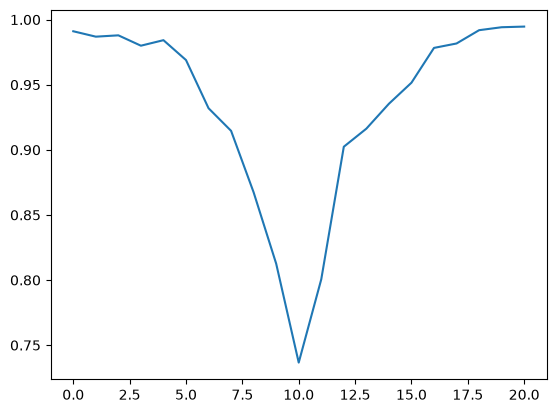

In [106]:
plt.plot(overlaps)